# `Genesis` demo — mobile dual-arm FR3 

This notebook shows how to use the reusable `RobotScene` class from
`scripts/scene_robot_tables.py`:

1. **Start** the simulation environment
2. **Drive the base** around the scene (forward / strafe / rotate)
3. **Control individual joints** (arms + grippers)
4. **Use IK** to move the left / right arm end-effectors

### 0. Install dependencies (For AUPLC and Google Colab)

The install commands below are grouped by platform and commented out by default.

**Uncomment the block matching your platform** and run the cell — skip it entirely on a
local `uv sync` install (dependencies are already present):

> Google Colab: first set the runtime to GPU — **Runtime → Change runtime type → GPU**.

> On a fresh Colab / AUPLC session, **restart the kernel** after the install cell finishes.

In [ ]:
# AUPLC Dependencies
# !pip install --no-deps git+https://github.com/yxzhan/fr3-genesis.git@main
# !pip install usd-core

# Colab Dependencies
# !pip install --no-deps git+https://github.com/yxzhan/fr3-genesis.git@main
# !apt update -qq && apt install -qq libnvidia-gl-580
# !pip install genesis-world==0.4.6 usd-core

## 1. Start the simulation

Toggle **`HEADLESS`** below:
* `HEADLESS = True` — no viewer window; you only see the inline frames (`show()`) and the
  final mp4. This is the right choice for a remote/browser kernel with no display.
* `HEADLESS = False` — opens the native Genesis viewer window (a separate desktop window;
  it does **not** appear inside the browser). Requires a display (`DISPLAY` set). The inline
  `show()` frames and the mp4 still work in addition to the window.

In [2]:
import os
import numpy as np
from IPython.display import display

# fr3_genesis is installed as a package (uv sync), so import RobotScene directly.
from fr3_genesis import RobotScene

# Toggle this: True = no viewer window (offscreen only),
#              False = also open the native Genesis viewer (needs a display).
HEADLESS = True
SAVE_VIDEO = True

sim = RobotScene(headless=HEADLESS, asset_format="mjcf")
# sim = RobotScene(headless=HEADLESS, asset_format="usd")


if SAVE_VIDEO:
    sim.start_recording()   # begin accumulating frames for the final mp4

[I 06/09/26 09:54:38.298 3726] [shell.py:_shell_pop_print@25] Graphical python shell detected, using wrapped sys.stdout


[backend] using: amdgpu (precision=64)
[Genesis] [09:54:41] [INFO] ╭───────────────────────────────────────────────╮
[Genesis] [09:54:41] [INFO] │┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈ Genesis ┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈│
[Genesis] [09:54:41] [INFO] ╰───────────────────────────────────────────────╯
[Genesis] [09:54:42] [INFO] Running on [Radeon 8060S Graphics] with backend gs.amdgpu. Device memory: 64.00 GB.
[Genesis] [09:54:42] [INFO] 🚀 Genesis initialized. 🔖 version: 0.4.6, 🎨 theme: light, 🌱 seed: None, 🐛 debug: False, 📏 precision: 64, 🔥 performance: False, 💬 verbose: INFO


[Genesis] [09:54:49] [WARNING] Link 'imagetostl_mesh_0_009' has dubious mass 138.425 compared to the estimate from geometry 0.091 given material density 600.
[Genesis] [09:54:49] [WARNING] Link 'imagetostl_mesh_0_011' has dubious mass 15.822 compared to the estimate from geometry 0.017 given material density 600.
[Genesis] [09:54:49] [WARNING] Ignoring inertia matrix of link 'argo_drive_front_link' because center of mass is not specified.
[Genesis] [09:54:49] [WARNING] Ignoring inertia matrix of link 'argo_drive_rear_link' because center of mass is not specified.
[Genesis] [09:54:53] [WARNING] Neutral robot position (qpos0) exceeds joint limits.
[Genesis] [09:55:00] [WARNING] Filtered out geometry pairs causing self-collision for the neutral configuration (qpos0): (93, 104), (93, 105), (93, 108), (93, 109), (95, 105), (97, 109), (116, 120), (116, 121), (116, 128), (117, 122), (117, 123), (117, 136), (127, 131), (135, 139). Consider tuning Morph option 'decompose_robot_error_threshold' 

In [3]:
import matplotlib.pyplot as plt

def show(img, title=None):
    """Render one frame from the offscreen camera and display it inline."""
    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

## 2. Drive the base

`sim.set_base_velocity(vx, vy, wz, steps)` sets a body-frame velocity and advances the simulation:
* `vx` — forward (+) / back (−), m/s
* `vy` — strafe left (+) / right (−), m/s
* `wz` — rotate in place, left (+) / right (−), rad/s

The dual-steer wheels and a heading-hold controller are handled internally.

start base pose: [ 0.   4.5 -0. ]


driving forward: 100%|██████████| 100/100 [00:01<00:00, 52.38it/s]


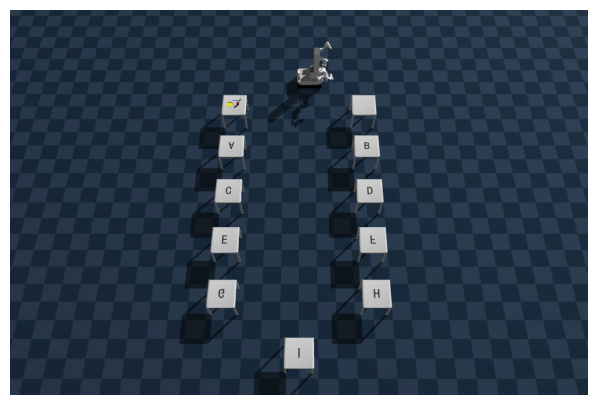

rotating: 100%|██████████| 100/100 [00:01<00:00, 59.78it/s]


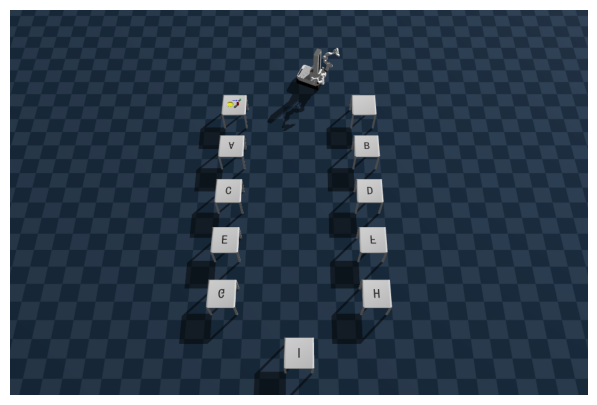

end base pose: [3.910e-01 4.543e+00 2.000e-03] yaw(deg): -24.6


In [4]:
sim.scene.reset()
sim.stop_base()

print("start base pose:", np.round(sim.get_base_pose()[0], 3))

sim.set_base_velocity(1.0, 0.0, 0.0)    # forward
sim.step(100, "driving forward")
show(sim.render())

# sim.set_base_velocity(-1.2, 0.0, 0.0)    # backward
# sim.step(500, "driving backward")
# show(sim.render())

sim.set_base_velocity(0.0, 0.0, -1.2)   # rotate in place (right)
sim.step(100, "rotating")
show(sim.render())


# sim.set_base_velocity(0.0, 0.5, 0.0)    # strafe left
# sim.step(200, "after strafing left")
# show(sim.render())

sim.stop_base()
pos, yaw = sim.get_base_pose()
print("end base pose:", np.round(pos, 3), "yaw(deg):", round(np.degrees(yaw), 1))

## 3. Control individual joints

Each arm has 7 joints and a 2-finger gripper. Set position targets directly:
* `sim.set_arm(side, q)` — 7 joint angles (rad) for `side` in `'left'` / `'right'`
* `sim.set_gripper(side, opening)` — finger opening in meters (`0.0` closed .. `0.04` open)

Targets are held every simulation step; pass `step=True, steps=N` to advance immediately.

left arm q (rad): [-0.   -1.5   0.01 -2.2   0.    1.5   0.78]


arm joint controlling: 100%|██████████| 100/100 [00:01<00:00, 60.40it/s]


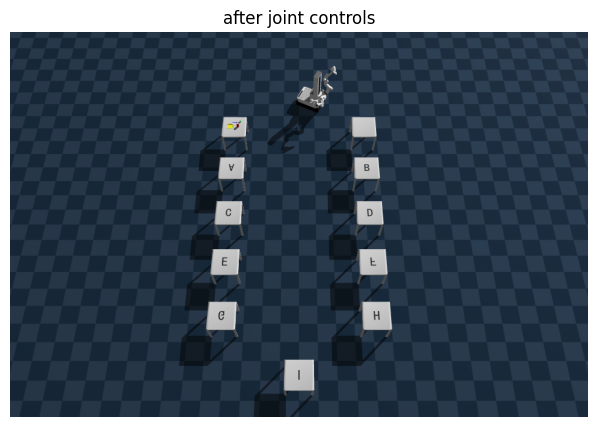

In [5]:
# Read the current left-arm joint angles, then bend joint 4 (elbow) and joint 6 (wrist).
q_left = sim.get_arm("left").copy()
print("left arm q (rad):", np.round(q_left, 2))

q_left[3] += 0.6    # joint4
q_left[5] -= 0.5    # joint6
sim.set_arm("left", q_left)
sim.step(100, "arm joint controlling")

# Torso Lift
# sim.set_spine(0.3)
# sim.step(30, "Torso Lifting")

# # Close then open the left gripper.
# sim.set_gripper("left", 0.0)     # close
# sim.step(50)
# sim.set_gripper("left", 0.04)    # open again
# sim.step(50)

show(sim.render(), "after joint controls")


## 4. Pick and place a cube with IK

A small green cube sits on the cutlery table. We:

1. **Teleport** the base next to the table with `sim.teleport_base(x, y, yaw)` so the
   right arm can reach the cube (instant, no driving).
1. Read the cube's live pose with `sim.cube.get_pos()`.
1. Run a **right-arm pick-and-place** using the IK move primitive `sim.move_ee(side, pos)`
   (moves the finger TCP along a straight line) plus `sim.set_gripper(side, opening)`:
   open → above cube → down → close → lift → over a drop spot → open gripper (drop).

The numeric poses below (teleport target, approach/drop heights) are good starting
points; tweak them if the arm doesn't quite reach or the grasp slips.

teleported in front of the table: 100%|██████████| 100/100 [00:01<00:00, 57.20it/s]


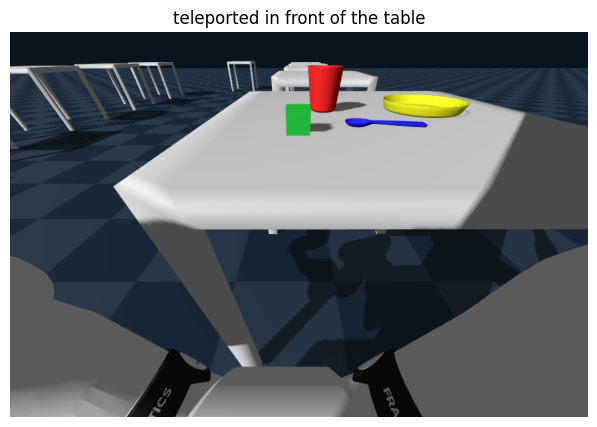

cube at: [-1.82  3.18  0.77]


Torso Lifting: 100%|██████████| 200/200 [00:03<00:00, 56.35it/s]


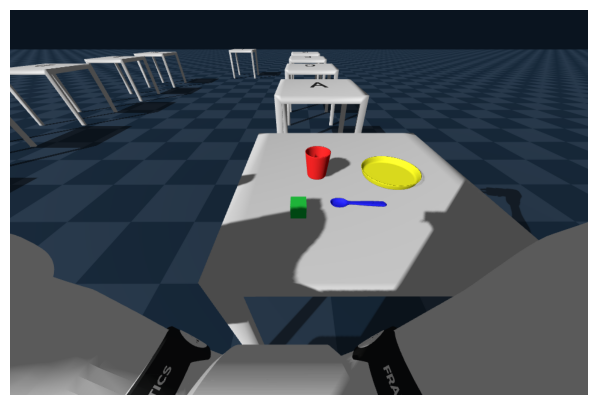

right TCP start: [-2.511  3.405  1.1  ]


hover above the cube: 100%|██████████| 50/50 [00:00<00:00, 59.89it/s]


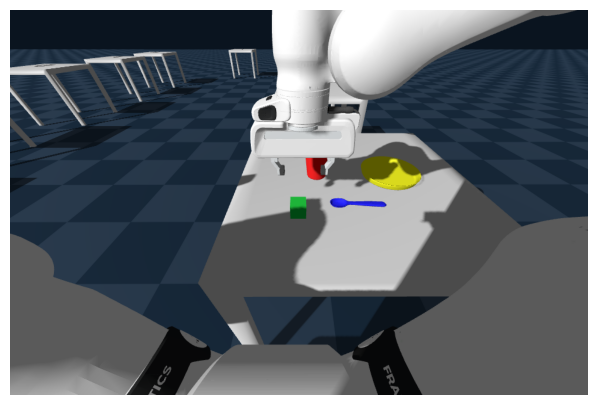

descend to the cube: 100%|██████████| 30/30 [00:00<00:00, 64.56it/s]


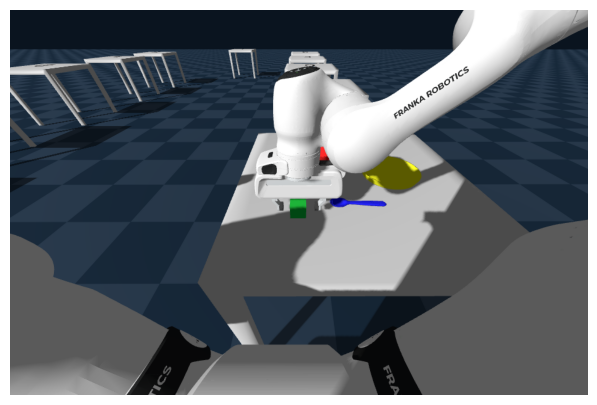

grasped the cube: 100%|██████████| 30/30 [00:00<00:00, 57.72it/s]


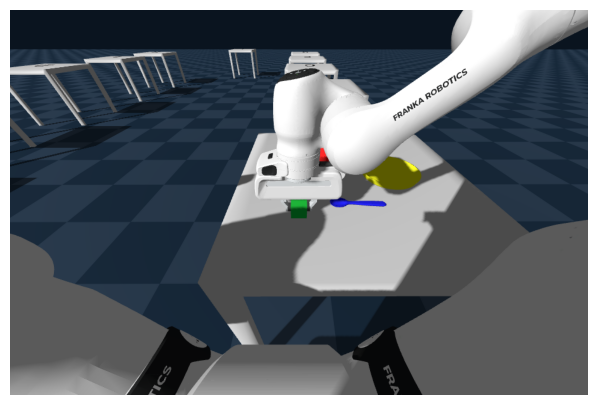

lift straight up: 100%|██████████| 30/30 [00:00<00:00, 58.10it/s]


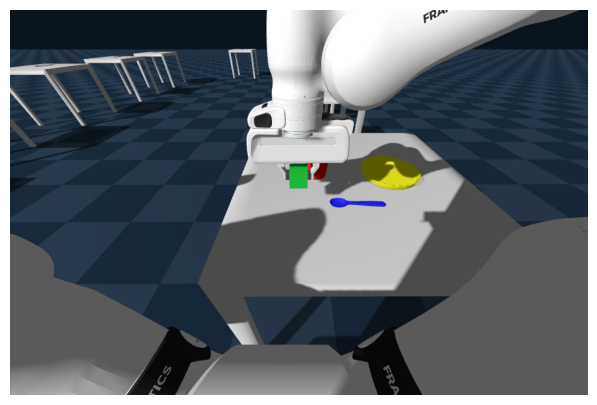

travel over the drop spot: 100%|██████████| 50/50 [00:00<00:00, 58.34it/s]


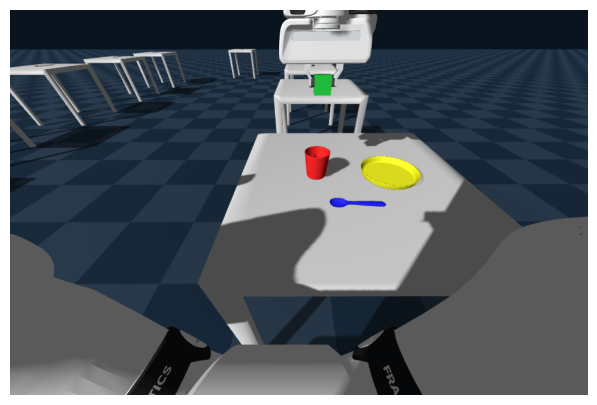

Release Gripper: 100%|██████████| 100/100 [00:01<00:00, 57.79it/s]


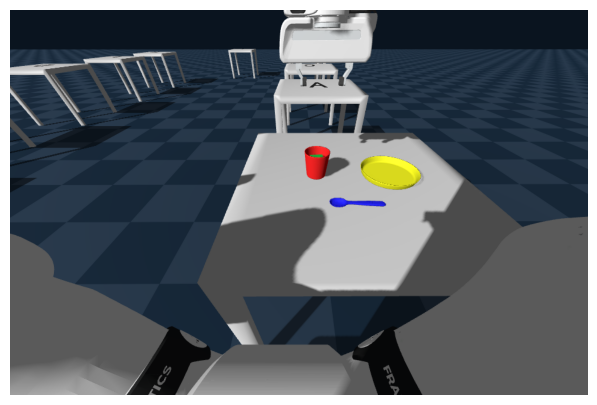

cube final pos: [-1.88   2.998  0.797]


In [6]:
# --- 0. reset the arms to the tucked hold pose (undo the earlier joint/IK moves) ---
# sim.step(200, "pausing")

# sim.scene.reset()
# sim.reset_pose()

# --- 1. teleport to the OPEN FRONT (+y) side of the cutlery table
sim.teleport_base(-1.8, 4, yaw=-np.pi / 2)
sim.step(100, "teleported in front of the table")
show(sim.render_head(), "teleported in front of the table")

# --- 2. read the cube's live pose (it has settled onto the table) ---
cube = sim.cube.get_pos().cpu().numpy()
print("cube at:", np.round(cube, 3))
sim.cam.set_pose(
    pos=cube + [0, -1.5, 1.5],
    lookat=cube,
)

side = "right"
APPROACH = np.array([0.0, 0.0, 0.15])   # 15 cm above a target before descending
GRASP = np.array([0.0, 0.0, 0.05])      # grasp-height clearance above the cube centre
# DROP_SPOT = np.array([-2.12, 3, 0.85])  # drop spot: Plate
DROP_SPOT = np.array([-1.88, 3, 0.92])  # drop spot: Bowl


# --- 3. right-arm pick-and-place ---
sim.set_spine(0.3)
sim.set_gripper(side, 0.04)             # open
sim.step(200, "Torso Lifting")
show(sim.render_head())

print("right TCP start:", np.round(sim.get_ee_pos(side), 3))
sim.move_ee(side, tuple(cube + APPROACH))   # hover above the cube
sim.step(50, "hover above the cube")
show(sim.render_head())

sim.move_ee(side, tuple(cube + GRASP))
sim.step(30, "descend to the cube")
show(sim.render_head())

sim.set_gripper(side, 0.0)
sim.step(30, "grasped the cube")
show(sim.render_head())

sim.move_ee(side, tuple(cube + APPROACH))
sim.step(30, "lift straight up")
show(sim.render_head())

sim.move_ee(side, tuple(DROP_SPOT + APPROACH))
sim.step(50, "travel over the drop spot")
show(sim.render_head())

sim.set_gripper(side, 0.04)
sim.step(100, "Release Gripper")
show(sim.render_head())

print("cube final pos:", np.round(sim.cube.get_pos().cpu().numpy(), 3))

## 5. Save and embed the recorded video

Everything above was recorded (we called `start_recording()` in step 1). Write it to an
mp4 and embed it inline — the second way to visualize the run.

In [7]:
from IPython.display import Video

try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _HERE = os.path.abspath(".")

result = sim.save_video(os.path.join(_HERE, "videos", "robot_scene_tables.mp4"))
if result is not None:
    top_path, head_path = result
    display(Video(top_path, embed=True, width=720))
    display(Video(head_path, embed=True, width=720))
else:
    print("No video to display (set SAVE_VIDEO = True in the first cell to record).")

✓ Saved top-down video to /opt/workspace/fr3-genesis/notebooks/videos/robot_scene_tables_top.mp4
✓ Saved head-camera video to /opt/workspace/fr3-genesis/notebooks/videos/robot_scene_tables_head.mp4
